<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Patricio Espinoza Acuña.
- Nombre de alumno 2: Javiera Romero Orrego.

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [2]:
!uv add nltk lightgbm xgboost optuna shap scikit-learn plotly

Resolved 147 packages in 25ms
Audited 139 packages in 31ms


In [3]:
import warnings

import nltk
import optuna
import pandas as pd
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

/Users/javi/Desktop/laboratorio/MDS7202/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [4]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [5]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [6]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [7]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [8]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> **Respuesta:**

> 1. Un modelo baseline suele ser el modelo más simple o ingenuo aplicable al problema, por lo que es perfecto como un punto de partida, suelen ser fáciles y rápidos de implementar, además de poco costosos computacionalmente. Sirve establecerlo antes ya que nos permitirá evaluar realmente el desempeño de modelos futuros y justificar la elección de un modelo más complejo, si por ejemplo empezáramos a resolver un problema con una red neuronal compleja y este nos entrega una métrica de f1, recall y precision de aprox 0,8 pero luego al probar un modelo simple también nos entrega métricas similares, entonces el uso de un modelo más complejo no estaría para nada justificado dado su desempeño y costo computacional.

> 2. El DummyClassifier sirve como baseline ya que realiza las clasificaciones de manera aleatoria, en particular esto permite ignorar las features de entrada del modelo, y por tanto, al compararlo con otro modelo que se entrene y que si considere a las features es posible decir que dicho modelo resulta mejor que predicción aleatorias. Que un modelo real no logre superar el rendimiento del DummyClassifier significa que es peor que predicciones aleatorias y por tanto no está ocurriendo un aprendizaje de como se relacionan las features con las etiquetas definidas. Esto implicaria que el modelo no tiene la capacidad de ajustarse a los datos o también que estos últimos necesitan de un refinamiento.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [9]:
#### Código aquí ####
# 1. Pipeline con preprocessing_transformer y DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

# 2. Holdout estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    df_comics.drop(columns=["alignment"]),
    df_comics["alignment"],
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_comics["alignment"],
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print("Pipeline con DecisionTreeClassifier:")
print(classification_report(y_test, y_pred))


# 3. Pipeline con preprocessing_transformer y DummyClassifier

pipeline_dummy = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DummyClassifier(random_state=RANDOM_STATE)),
    ]
)

# 4. classification report del baseline con DummyClassifier
pipeline_dummy.fit(X_train, y_train)
y_pred_dummy = pipeline_dummy.predict(X_test)
print("Pipeline con DummyClassifier:")
print(classification_report(y_test, y_pred_dummy))

Pipeline con DecisionTreeClassifier:
              precision    recall  f1-score   support

         Bad       0.47      0.48      0.47        86
        Good       0.68      0.64      0.66       148
     Neutral       0.10      0.13      0.12        23

    accuracy                           0.54       257
   macro avg       0.42      0.42      0.42       257
weighted avg       0.56      0.54      0.55       257

Pipeline con DummyClassifier:
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        86
        Good       0.58      1.00      0.73       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.58       257
   macro avg       0.19      0.33      0.24       257
weighted avg       0.33      0.58      0.42       257



### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> **Respuesta:**

> El DecisionTreeClassifier no supero al DummyClasifier en accuracy, aunque si en los macro y weighted avg de f1-score. Dado que los resultados fueron bajos se puede concluir que el modelo de DecisionTree no logró aprender correctamente las relaciones de los datos para predecir 'alighment' en base a los datos crudos.

> 1. El accuracy puede ser una métrica engañosa ya que podemos tener un desbalance de clases, y esta métrica es sensible a dicho problema. Si en nuestro dataset tenemos muchos más personajes buenos que malos entonces si siempre adivinamos que el personaje es bueno, sin aprender nada realmente de los datos, igualmente podríamos obtener un buen accuracy solo debido al desbalance. En el caso del modelo dummy nos permite identificar inmediatamente que hay un problema con la estructura de los datos en sí ya que estamos obteniendo una métrica "alta" de accuracy (0,58) simplemente haciendo las predicciones de manera aleatoria. No hay una métrica en específico correcta cuando hay desbalance, más bien debemos analizar que tipo de errores queremos minimizar y ver las métricas considerando esto, podemos ver el recall cuando necesitamos evitar falsos negativo, precision cuando queremos evitar falsos positivos y f1 (o f-beta) si necesitamos penalizar ambos errores, además podemos analizar las métricas mencionadas en conjunto entendiendo que significa cada una y buscando un modelo mas integral en sus resultados.

> 2. El parametro stratify permite que las clases de 'alignment' estén repartidas de forma proporcional tanto en el conjunto de train como el de test respecto a la distribución original de los datos. Esto evita que el conjunto de entrenamiento pueda tener una clase predominante sobre la que el modelo aprenda, y por consiguiente, los resultados sobre el conjunto de test, en donde la clase puede no ser la predominante, den scores no confiables.

> 3. Si se puede considerar que el clasificador es mejor que la versión aleatoria pese a que tiene un accuracy menor, el cual ya discutimos que es una métrica engañosa. Por ejemplo, su metrica de weighted f1-score y macro f1-score son más altas, denotando un mayor aprendizaje del modelo. Asimismo, en base a los resultados de accuracy=0.51, macro avg=0.39 y weighted avg=0.52 si se tiene confianza que se clasifica mejor que mediante un dado de 3 caras.

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**

El Bagging es una técnica de ensamblaje que se basa en el concepto de la "sabiduría de la mayoría" donde los individuales pueden no estar cerca de la realidad pero el conocimiento conjunto de varios si lo estará, en términos de modelos se traduce a que en vez de confiar en un solo modelo, hacemos un comité de modelos y promediamos sus resultados para obtener el veredicto final. 

Los subconjuntos de datos de entrenamiento se obtienen mediante bootstrap sampling, el cual consiste en seleccionar datos de forma aleatoria y con repetición hasta tener un conjunto de igual tamaño que el original para cada modelo. Cada modelo tiene distintos subconjuntos de los datos de entrenamiento, aunque pueden haber instancias repetidas debido al muestro con reemplazo. Dado este proceso explicado que es aleatorio y con repetición es que no necesariamente se usa todo el dataset en cada uno, si repetimos filas, lo datos no serán exactamente iguales, habrán instancias que en el original eran únicas que ahora estarán repetidas. Los datos que quedan fuera de cada subconjunto son llamados Out-Of-Bag (OOB) y se pueden utilizar como datos de validación.

Sobre cada subconjunto se entrenan modelos generalmente de árboles llamados weak learners, estos se entrenan de forma independiente entre si y gracias a esto se pueden paralelizar los procesos para ser más eficiente.

Una vez que el modelo está entrenado pasamos a poder combinarlos. Para el caso de clasificación, los modelos se combinan usando un sistema de votación mayoritaría que determinará la respuesta del modelo final, mientras que para el caso de regresión se utiliza el promedio de las predicciones dado que tendremos valores numéricos continuos, este resultado será la respuesta final del modelo.

---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [10]:
# Pipeline preprocessing_transformer con RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ]
)

# Entrenar con holdout estratificado 80/20
pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

# Entrenar y reportar classification report del pipeline con RandomForestClassifier
print("Pipeline con RandomForestClassifier:")
print(classification_report(y_test, y_pred_rf))

Pipeline con RandomForestClassifier:
              precision    recall  f1-score   support

         Bad       0.67      0.35      0.46        86
        Good       0.66      0.93      0.77       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.65       257
   macro avg       0.44      0.43      0.41       257
weighted avg       0.60      0.65      0.60       257



### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:** 

> Al comparar las métricas (DecisionTree -> RandomForest) se puede observar que el RandomForest no mejoró respecto al baseline, esto ya que la Accuracy paso de (0.51 -> 0.63), f1-score macro avg (0.39 -> 0.38) y f1-score weighted avg (0.52 -> 0.59), lo que sumado a los f1-score a nivel de clase muestra que RandomForest está tendiendo a predecir por la clase mayoritaria, generando la ilusión de un mejor desempeño. Esto se puede comprar ya que la Clase Bad paso de 0.43 a 0.40 (86 Instancias), Neutral paso de 0.11 a 0.0 (23 Instancias) y Good paso de 0.64 a 0.75 (148 instancias), es decir, se está prediciendo más por la clase mayoritaria que por un correcto aprendizaje de los datos.   

> Basado en el algoritmo visto anteriormente este efecto se puede dar justamente debido al sampleo aleatorio de muestras para los conjuntos de entrenamiento, las cuales sufrieron un bias debido al desbalance inicial en la distribución de clases en los datos.

> Por otra parte, al comparar las métricas (DummyClassifier -> RandomForest) podemos ver que el caso mencionado anteriormente es aún más crítico para el Dummy, pues para la clase Bad y Neutral el f1-score es de 0.0, mientras que para la clase Good es de 0.75. En este caso, RandomForest es ligeramente mejor puesto que realiza predicciones correctas para la Clase Bad.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**

A diferencia del Bagging en los que los modelos son entrenados en paralelo y de forma independiente entre sí, en el Boosting cada modelo (excepto el primero) es entrenado basado en los resultados de uno previo, funcionando de manera iterativa. En particular, Boosting permite que los árboles siguientes se enfoquen en mitigar las predicciones incorrectas, volviendolo un algoritmo secuencial y dependiente.

Cada modelo sabe en que instancias enfocarse debido a que se ocupan técnicas para concentrarse en corregir el error del modelo anterior, una es que se toman los errores del anterior y se les asigna un peso (weight) mayor. De esta forma, durante las iteraciones del modelo equivocarse en dichas instancias será más grave. La otra manera es que el modelo se entrena directamente sobre los residuales (errores) del modelo anterior en vez de las etiquetas originales, concentrandose en predecir el residuo

Las predicciones de los modelos se combinan mediante la combinación aditiva de todos los modelos entrenados, considerando qué tan bien aprendió cada uno, para la decisión final en el caso de AdaBoost cada modelo además recibe un peso según que tan bien clasifica, y se suman las predicciones de cada modelo ponderadas por sus pesos respectivos, en el caso de GradientBoost cuando el learning rate es constante simplemente sumamos los resultados de cada modelo para crear la decision final.

La diferencia entre XGBoost y LightGBM radica en que XGBoost requiere que las etiquetas sean númericas y LightGBM no necesariamente, esto se debe a la implementación de cada uno, debido al uso de gradientes para las optimizaciones y regularizaciones originalmente XGBoost solo aceptaba valores numéricos, sin embargo LightGBM cuenta con una etapa interna en la que se mapean variable categóricas a numéricas.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [11]:
# 1. Creación de LabelEncoder, ajustandolo sobre y_train y transformando y_train e y_test
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

le = LabelEncoder()
le.fit(y_train)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

# 2. Pieline con preprocessing_transformer y XGBClassifier

pipeline_xgb = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)),
    ]
)

# 3. Entrenar con holdout estratificado 80/20
pipeline_xgb.fit(X_train, y_train_encoded)
y_pred_xgb = pipeline_xgb.predict(X_test)

# 4. Reportar resultados decodificando las predicciones con el LabelEncoder
y_pred_xgb_decoded = le.inverse_transform(y_pred_xgb)
print("Pipeline con XGBClassifier:")
print(classification_report(y_test, y_pred_xgb_decoded))


# 5. Pipeline con preprocessing_transformer y LGBMClassifier
pipeline_lgbm = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)),
    ]
)

# 6. Entrenar con holdout estratificado 80/20
pipeline_lgbm.fit(X_train, y_train_encoded)
y_pred_lgbm = pipeline_lgbm.predict(X_test)

# 7. Reportar resultados decodificando las predicciones con el LabelEncoder
y_pred_lgbm_decoded = le.inverse_transform(y_pred_lgbm)
print("Pipeline con LGBMClassifier:")
print(classification_report(y_test, y_pred_lgbm_decoded))

Pipeline con XGBClassifier:
              precision    recall  f1-score   support

         Bad       0.56      0.42      0.48        86
        Good       0.68      0.84      0.75       148
     Neutral       0.50      0.17      0.26        23

    accuracy                           0.64       257
   macro avg       0.58      0.48      0.50       257
weighted avg       0.62      0.64      0.62       257

Pipeline con LGBMClassifier:
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257



### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**

Al comparar XGBoost con los Baseline (DecisionTree y DummyClassifier) podemos observar que obtiene un Accuracy más alto en conjunto con un f1-score por clase más altos, lo que indica que el modelo aprendió y no solo clasificó basándose en la clase mayoritaria. (f1-score macro avg: 0.45 y f1-score weighted avg: 0.60)

Por otra parte, al comparar el LightGBM con los Baseline, podemos observar que aunque es el que alcanza el Accuracy más alto entre todos los modelos (0.68), para la clase minoritaria 'Neutral' obtiene un f1-score de 0.0, es decir predice principalmente entre Bad y Good. Dado que el contexto del problema radica en clasificar al personaje dentro de una de las 3 cateogorías, es importante tener una precisión en la clase Neutral, y por tanto un modelo más balanceado como XGBoost resulta mejor que LightGBM.

Finalmente, al comparar a XGBoost y LightGBM contra RandomForest podemos observar que ambos resultan mejores, por una parte, aunque XGBoost tiene la misma Accuracy ocurre que también tiene un f1-score macro avg mayor. Y en el caso de LightGBM, ambos modelos tienen 0.0 de f1-score para la Clase Neutral, pero LightGBM tiene un mejor rendimiento en las dos clases restantes.

El mejor desempeño macro fue el del modelo XGBoost y LightGBM, mejorando ambos respecto a los Baseline. Dado que ambos modelos usan Boosting se puede atribuir que obtuvieron mejores rendimientos debido a la correción de sus errores, algo que no ocurria en los modelos de árboles pasados. Por otra parte, la diferencia con respecto a la clase minoritaria entre XGBoost y LightGBM se puede deber a como operan sus algoritmos, donde LightGBM tiende a hacer un sobre-ajuste a nivel de hoja cuando se tienen pocos datos ya que busca minizar la función de pérdida, mientras que XGBoost maneja este tipo de situación mejor al crecer de manera equilibrada entre árboles,

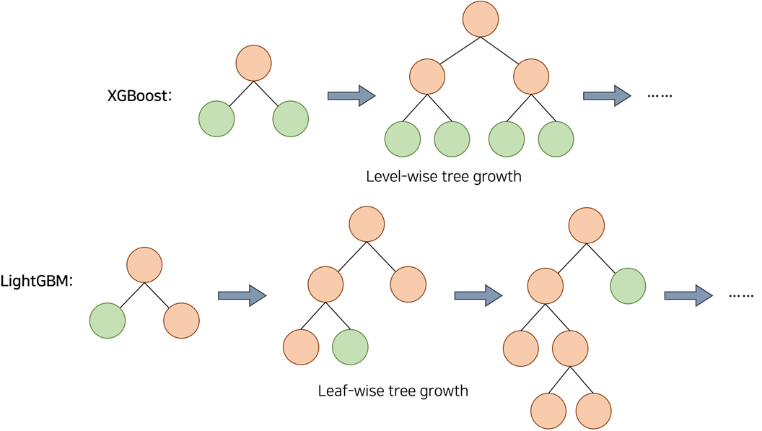

Pipeline con DecisionTreeClassifier:
```
              precision    recall  f1-score   support

         Bad       0.41      0.43      0.42        86
        Good       0.66      0.61      0.64       148
     Neutral       0.10      0.13      0.11        23

    accuracy                           0.51       257
   macro avg       0.39      0.39      0.39       257
weighted avg       0.53      0.51      0.52       257
```

Pipeline con DummyClassifier:
```
              precision    recall  f1-score   support

         Bad       0.00      0.00      0.00        86
        Good       0.58      1.00      0.73       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.58       257
   macro avg       0.19      0.33      0.24       257
weighted avg       0.33      0.58      0.42       257
```

Pipeline con RandomForestClassifier:
```
              precision    recall  f1-score   support

         Bad       0.60      0.30      0.40        86
        Good       0.63      0.91      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.41      0.40      0.38       257
weighted avg       0.57      0.63      0.57       257
```

Pipeline con XGBClassifier:
```
              precision    recall  f1-score   support

         Bad       0.55      0.42      0.47        86
        Good       0.68      0.84      0.75       148
     Neutral       0.33      0.09      0.14        23

    accuracy                           0.63       257
   macro avg       0.52      0.45      0.45       257
weighted avg       0.60      0.63      0.60       257
```

Pipeline con LGBMClassifier:
```
              precision    recall  f1-score   support

         Bad       0.60      0.56      0.58        86
        Good       0.72      0.86      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.68       257
   macro avg       0.44      0.47      0.45       257
weighted avg       0.61      0.68      0.64       257
```

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**

El stacking es otro método de ensamblaje más, el cual se basa en combinar las fortalezas de varios modelos heterogéneos (modelos base) para luego ocuparlos de input para un modelo meta-learner que se encargará de mezclarlos de manera óptima. 

Los modelos base son nuestros aprendices de primer nivel y su objetivo es procesar las características originales de los datos y generar sus predicciones de manera independiente entre ellos, la idea es que cada modelo base vaya capturando un patrón relevante en los datos según la naturaleza del modelo que estamos ocupando (por ejemplo un modelo de árbol capturaría la no-linealidad de los datos). Cada modelo se entrena con los datos de entrenamiento originales y genera las predicciones sobre los datos de validación, en específico en estos modelos se utiliza cross-validation, cada modelo predice el fold que no fue entrenado, es decir utiliza esa data "out-of-fold" como datos de validación. El cross-validation se utiliza para evitar data-leakage, si evaluaramos con los mismos datos de entrenamiento con los que fueron entrenados obtendríamos resultados sobreajustados, reflejando un error muy bajo que no sería acorde a la realidad. 

El meta-learner o meta-modelo por su parte, recibe como input una matriz con las predicciones hechas por los distintios modelos bases y el vector con las etiquetas reales. Su objetivo a diferencia de los modelos base ya no será aprender patrones de los datos, si no, buscar la manera de combinar estas predicciones para generar la predicción final más acertada posible, es decir aprende de las predicciones de distintos modelos y las relaciones que hay entre estas, así aprende cuales predicciones son más adecuadas según la situación. 

El stacking supera a cada modelo por si solo ya que permite que colaboren entre sá, así tomando las ventajas de cada uno y mejorando las contras que tendrían por si solos, mejorando el rendimiento al usarlos en conjunto de manera adaptativa. Aprovecha de la diversidad de modelos el hecho de que algoritmos distintos pueden capturar distintos patrones en un mismo set de datos y de manera similar, equivocarse en distintos casos en un mismo set de datos, por lo que al combinarlos logramos adaptarnos a más casos y reforzar las partes en las que se equivocaba cada uno de manera individual, parchando las desventajas de unos con las ventajas de otros. 


---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [12]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB

# Modelos base para el stacking
estimators = [
    ("multiNB", MultinomialNB()),
    ("sgd", SGDClassifier(random_state=RANDOM_STATE)),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
]

# Pipeline para meta-learner con StandardScaler y StackingClassifier
pipe_stack = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "model",
            StackingClassifier(
                estimators=estimators,
                final_estimator=LogisticRegression(
                    random_state=RANDOM_STATE
                ),  # Se elige LogisticRegression como meta-learner por su buena interpretabilidad, bajo costo y baja complejidad.
                cv=3,
                n_jobs=-1,
            ),
        ),
    ]
)

pipe_stack.fit(X_train, y_train)
y_pred_stack = pipe_stack.predict(X_test)

# Reportar classification report del stacking
print("Pipeline con StackingClassifier:")
print(classification_report(y_test, y_pred_stack))

Pipeline con StackingClassifier:
              precision    recall  f1-score   support

         Bad       0.70      0.49      0.58        86
        Good       0.69      0.91      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.69       257
   macro avg       0.46      0.47      0.45       257
weighted avg       0.63      0.69      0.64       257



### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**

Multinomial Naive Bayes es un modelo probabilístico que funciona bien en contextos de frecuencias/conteos, como en este caso se usa texto se espera que funciona bien también. Este modelo aporta en su capacidad para modelar la distribución de las características bajo el supuesto de independencia entre ellas.

El SGDClassifier es un modelo lineal entrenado mediante descenso de gradiente estocástico (SGD). Este modelo genelariza bien en espacios de alta dimensionalidad, como lo es cuando se trabaja con texto y aporta en aprender directamente una frontera de decisión discriminativa.

Finalmente, el DecisionTreeClassifier permite capturar relaciones no lineales e interacciones complejas entre las variables, aportando asi en complementar los otros modelos base mediante la detección de patrones distintos.

Se eligen estos 3 modelos ya que tienen fortalezas distintas por lo que aportarán al modelo final colaborando entre ellos. 

Stacking sí mejoró con respecto a los modelos probados anteriormente, mostrando el mejor accuracy hasta el momento de 0.69, además vemos una mejora en precision con respecto a los demás modelos para la clase "Bad" mostrando que está aprendiendo más robustamente de los datos, sin embargo la diferencia de distribución de clases sigue afectando al modelo, como podemo ver en los resultados de la clase minoritaria "Neutral". Se le atribuye la mejora del modelo al hecho de que está combinando las ventajas de todos los modelos base que utiliza, mezclando sus fortalezas, esto se ve en que obtenemos métricas más equilibradas y en específico tenemos los mejores f1 para "Bad" y "Good" de momento (empatado con LightGBM para "Good"). Finalmente, creemos que se puede seguir mejorando los resultados a través de la optimización de hiperparámetros del modelo.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**

1. Los hiperparámetros de un modelo corresponden a variables que establecemos antes de entrenar al modelo, y que afectan directamente en cómo se realiza este aprendizaje y cómo se procesan los datos. A diferencia de los parámetros que el modelo aprende durante el entrenamiento estos no son aprendidos, si no configurados desde un inicio, dependen de lo que se descubrió previamente del modelo, luego los parámetros aprendidos durante el entrenamiento tienen una dependencia a dichos hiperparámetros elegidos.  

2. Como se mencionó anteriormente, los hiperparámetros afectarán directamente a los parámetros que se aprenden durante el entrenamiento y así mismo afectarán a los resultados finales, es por esto que deben ser elegidos en base a características del problema, por ejemplo cuál métrica se busca optimizar. Si utilizamos los parámetros por defecto podemos caer en un sub-ajuste, teniendo un modelo demasiado simple que no capture los patrones en los datos, así mismo nos podemos ir al otro extremo, y tener sobre-ajuste donde memorizemos los datos en ves de encontrar patrones generales, finalmente tenemos hiperparámetros que afectan al costo computacional, por lo que al usar los predeterminados podríamos estar ocupando más poder computacional de requerido, perdiendo recursos y gastando más tiempo. Dichos problemas se deben a que no estamos optimizando los hiperparámetros para nuestro problema específico y sus necesidades. 

3. GridSearchCV es un algoritmo de optimización de parámetros, este funciona probando todas las combinaciones posibles de hiperparámetros que le entregamos para encontrar la óptima, es decir entrena el modelo con cada una de esas combinaciones. Por esto mismo es que si le damos muchas opciones de cada hiperparámetro, la búsqueda se puede llegar a demorar un gran tiempo dependiendo de los recursos computacionales disponibles, pasando de algo que demoraría una hora a demorar días por ejemplo, siendo esta su limitación principal, crece multiplicativamente la cantidad de combinaciones cada vez que añadimos un parámetro a probar. 

4. Cada trial se evalúa con validación cruzada ya que, si se usara el conjunto de test ocurriría Data Leakage, por tanto, de esta forma se pueden ajustar los hiperparametros de forma segura garantizando que no hubo ninguna influencia sobre el conjunto de test. Asimismo, la validación cruzada permite ver que tanto variarían los resultados de acuerdo a los datos mediante métricas como desviación estándar (patrones/relaciones muy dependientes de los datos o más generalizables). 

La CV se puede reemplazar al crear conjuntos de entrenamiento, validación y test de forma permanente y sin cambios. La ventaja sería que reduciría el costo computacional requerido por la CV, mientras que las desventajas serian no tener información acerca de cómo varían las métricas y también un posible peor ajuste de hiperparametros ya que dependerán de las particiones elegidas para train/val/test.

5. Los samplers inteligentes a diferencia de GridSearch sí utilizan la información que ya saben, de las pruebas anteriores, para tomar decisiones, así evitando hacer búsquedas que no tienen sentido. Ahora aprendemos iterativamente qué configuraciones son mejores, dividiendo en un espacio de configuraciones buenas y malas para centrar la busqueda en las buenas. Será más eficiente ya que lograremos evitar probar configuraciones que desde un principio no serán óptimas, que GridSearchCV hubiera probado igualmente, además podemos obtener mejores resultados ya que a diferencia de GridSearch que solo prueba los valores que le damos, es decir trabaja con los valores de manera discreta, TPE puede acercarse mucho más al óptimo real, ya que naturalmente utiliza valores continuos, si a GridSearch le dieramos a probar learning rates de [0.001, 0.01, 0,1] y nuestro óptimo para dicho parámetro fuera 0.075, nos podemos acercar más a dicho valor utilizando TPE. 

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [13]:
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        [
            ("features", preprocessing_transformer),
            ("clf", LGBMClassifier(**params, random_state=RANDOM_STATE, verbose=-1)),
        ]
    )

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro")
    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [14]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 19. Best value: 0.465027: 100%|██████████| 50/50 [15:44<00:00, 18.88s/it]

Mejor F1-Macro: 0.4650

Mejores hiperparámetros:
  num_leaves: 105
  learning_rate: 0.18313839783098723
  max_depth: 7
  min_child_samples: 20
  subsample: 0.9306106931289139
  colsample_bytree: 0.5852306392660566
  reg_alpha: 2.726398818528333e-07
  reg_lambda: 3.4580541516447337e-06


Resultados:

Best trial: 19. Best value: 0.465027: 100%|██████████| 50/50 [14:39<00:00, 17.60s/it]
Mejor F1-Macro: 0.4650

Mejores hiperparámetros:
  num_leaves: 105
  learning_rate: 0.18313839783098723
  max_depth: 7
  min_child_samples: 20
  subsample: 0.9306106931289139
  colsample_bytree: 0.5852306392660566
  reg_alpha: 2.726398818528333e-07
  reg_lambda: 3.4580541516447337e-06

In [15]:
best_params = study.best_params

pipe_lgbm_opt = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(**best_params, random_state=RANDOM_STATE, verbose=-1)),
    ]
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
acc_scores = cross_val_score(pipe_lgbm_opt, X_train, y_train, cv=cv, scoring="accuracy")
print(f"Accuracy CV (mean): {acc_scores.mean():.4f}")

Accuracy CV (mean): 0.6537


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [16]:
from plotly.io import show

# Graficar historial de optimizacion de Optuna
fig = optuna.visualization.plot_optimization_history(study)
show(fig)

# Graficar importancia de hiperparámetros con Optuna
fig = optuna.visualization.plot_param_importances(study)
show(fig)

# Graficar visualizacion del comportamiento de los hiperparámetros con Optuna
fig = optuna.visualization.plot_parallel_coordinate(study)
show(fig)

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [17]:
#### Código aquí ####

pipe_lgbm_opt = Pipeline(
    [
        ("features", preprocessing_transformer),
        ("clf", LGBMClassifier(**best_params, random_state=RANDOM_STATE)),
    ]
)

pipe_lgbm_opt.fit(X_train, y_train_encoded)
y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

y_pred_lgbm_opt_decoded = le.inverse_transform(y_pred_lgbm_opt)
print("Pipeline con LGBMClassifier optimizado:")
print(classification_report(y_test, y_pred_lgbm_opt_decoded))

Pipeline con LGBMClassifier optimizado:
              precision    recall  f1-score   support

         Bad       0.56      0.52      0.54        86
        Good       0.72      0.84      0.77       148
     Neutral       0.50      0.09      0.15        23

    accuracy                           0.67       257
   macro avg       0.59      0.48      0.49       257
weighted avg       0.65      0.67      0.64       257



F1 MACRO original 0.45
F1 MACRO optimizado 0.49

Notamos un aumento de +0.04 en F1 macro al optimizar los hiperparámetros del modelo, esto nos muestra que ajustar dichos parámetros sí está ayudando a que el modelo generalize de mejor manera. 



### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.


1. Learning rate fue el hiperparámetro más importante según la gráfica de importancia de hiperparámetros de Optuna. Nos hace sentido esta importancia, ya que el learning rate es un parámetro que se queda constante a través de los árboles de LightGBM por lo que si el primer valor es muy pequeño o muy grande haciendo que se equivoque mucho, esto afectará subsecuentemente a los árboles que le siguen, teniendo mucho que corregir. A la hora de optimizar los hiperparámetros, se ocupó un rango amplio de valores para learning rate por lo que se debe haber visto expuesto a estos casos extremos mencionados. 

2. Nos muestra más informacion de las decisiones que toma el algoritmo para optimizar los parámetros, podemos ver claramente como funciona el algoritmo, viendo como la elección de ciertos parámetros está muy cargada hacia un solo lado, mostrando cómo el algoritmo puede eliminar gran parte de las opciones cuando busca el camino óptimo, además vemos que no hay una combinación única que nos lleve a buenos resultados, hay varios camino que nos llevan a un buen resultado del objective value. Al seleccionar el rango de la dimensión objective value podemos tener una visualización mucho más limpia y cómoda para el análisis, mostrandonos como se comportaron solo las mejores observaciones. 

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [18]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)


# Entrenar con holdout estratificado 80/20
lgbm_interp.fit(X_train_num, y_train_encoded)
y_pred_lgbm = lgbm_interp.predict(X_test_num)

# Reportar resultados decodificando las predicciones con el LabelEncoder
y_pred_lgbm_decoded = le.inverse_transform(y_pred_lgbm)
print("Pipeline con LGBMClassifier:")
print(classification_report(y_test, y_pred_lgbm_decoded))

Pipeline con LGBMClassifier:
              precision    recall  f1-score   support

         Bad       0.37      0.29      0.33        86
        Good       0.60      0.72      0.65       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.51       257
   macro avg       0.32      0.34      0.33       257
weighted avg       0.47      0.51      0.48       257



## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**

1. La Permutation Feature Importance (PFI) es un método de interpretación de importancia de variables que permuta las variables al tomar una específica y desordenar sus valores, el resto de los valores que no son de dicha característica quedan intactos. Al hacer esto desordenamos los valores y perdemos la relación con el resto de las variables (incluída la objetivo), esto se realiza solo en el conjunto de test. Para medir el impacto en el rendimiento del modelo se calculan las métricas de evaluación originales, es decir con los datos sin ninguna permutación y en el conjunto de test, para luego permutar la columna de la variable a la cual le queremos medir su impacto, pasamos este nuevo set con la columna permutada para generar nuevas predicciones, calculamos las nuevas métricas y comparamos con las originales. Si el resultado al haber permutado los valores de la columna son peores que los originales, entonces, la variable es importante, si da resultados similares o incluso mejores, significa que la variable no era relevante. 

2. Es preferible ocupar PFI por sobre los métodos de importancia nativos de los árboles de decisión, ya que estos últimos puede sufrir sesgos debido a alta cardinalidad dados los datos utilizados. Los árboles van eligiendo los puntos de corte basado en la variable que permite separar mejor los datos, es decir optimizar la disminución de la impureza, y si tenemos una variable de muchos valores únicos distintos el árbol tenderá a utilizarlas por sobre otras variables, sesgandolo hacia esta característica, el método nativo tenderá entonces a creer que dichas variables son más importantes para el modelo de manera artificial. 




---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [19]:
#### Código aquí ####

# Calculamos permutation_importance con n_repeats=30
# result = score original - score permutado
# result < 0 -> feature no importante
# result > 0 -> feature importante
import plotly.express as px
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgbm_interp, X_test_num, y_test_encoded, n_repeats=30, random_state=RANDOM_STATE, scoring="f1_macro"
)


perm_importance = pd.DataFrame(
    {
        "feature": NUMERICAL_FEATURES,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std,
    }
).sort_values("importance_mean", ascending=False)
print(perm_importance)


# Boxplot horizontal con plotly con importancia y varianza de cada feature

fig = px.bar(perm_importance, x="importance_mean", y="feature", orientation="h", error_x="importance_std", title="PFI ")

fig.update_layout(yaxis={"categoryorder": "total ascending"}, xaxis_title="Importancia media", yaxis_title="Feature")

fig.show()

              feature  importance_mean  importance_std
0  intelligence_score        -0.006014        0.020063
1      strength_score        -0.012777        0.023514
5        combat_score        -0.018331        0.015188
3    durability_score        -0.021454        0.020887
4         power_score        -0.025023        0.018797
2         speed_score        -0.033306        0.019938


### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**

La feature que tuvo más impotancia es intelligence_score, sin embargo, es poco significativa igualmente, obteniendo un promedio de -0.006014. Si nos hace sentido que todas estas variables sean poco significativas con el contexto del problema, tanto los personajes buenos como malos tienden a tener cualidades parecidas entre ellos, sería muy fome ver por ejemplo a superman peleando con un villano que no fuera ni fuerte ni inteligente, para tener batallas interesantes debemos tener personajes buenos y malos equiparados en sus skills. Al tratarse de cómics, esta industria viene de estados unidos y tiende a tener estereotípos bastante marcados, creemos que gracias a esto la inteligencia puede ser un poco mas importante que las demás, tendemos a ver muchos villanos que tiene profesiones "inteligentes" como "Doctor Octopus", "Lex Luthor", "Mr. Freeze" que son todos científicos.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**

1. Los SHAP values nos miden que tanto aporta cada variable en la predicción del modelo para poder interpretar los resultados. A diferencia del PFI que nos da resultados de importancia globales, SHAP nos permite analizar los resultados tanto de manera local, viendo la importancia de cada variable para una predicción en específico o de manera gloabl agregando estos valores, además SHAP nos permite ver como afecta direccionalmente cada variable permitiendo ver el cómo y el cuanto afecta. 

2. El base_value representa el promedio de las predicciones totales, es el punto de partida para poder interpretar la prediccion individual ya que representamos con respecto a este si cada característica actua de manera direccionalmente positiva o negativa para esa instancia en específico, mostrandonos hacia donde "empuja" la predicción desde este punto inicial que sería sin saber nada del resto de las características para ese caso.

3. TreeExplainer fue específicamente diseñado para usar SHAP values con modelos de árboles, aprovechando la estructura de estos para optimizar el cálculo. La principal ventaja con respecto a explainers genéricos es que requiere menos poder computacional y tiempo dado que usa la estructura del árbol para calcular los SHAP vañues, evitando tener que ocupar métodos de aproximación. 


---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

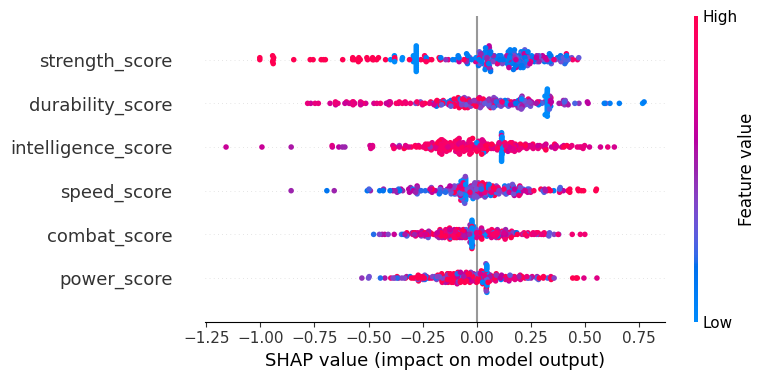

Personaje escogido: Deadpool
Clase predicha: Good


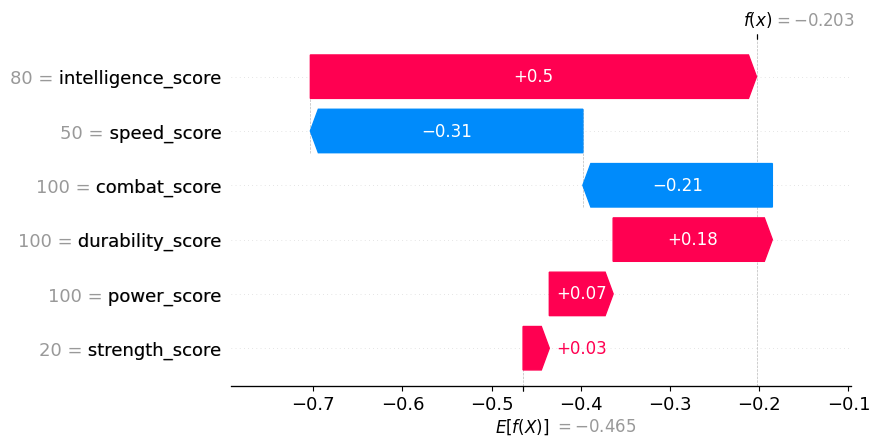

In [20]:
import shap

tree_explainer = shap.TreeExplainer(lgbm_interp)
shap_values = tree_explainer.shap_values(X_test_num)

# summary plot para ver importancia global y direccion para la clase "Good" filtrada
clase_good_idx = list(le.classes_).index("Good")
shap_values_good = shap_values[:, :, clase_good_idx]
shap.summary_plot(shap_values_good, X_test_num, feature_names=NUMERICAL_FEATURES)

# Waterfall de una instancia cualquiera de X_test_num
id = 1
clase_predicha_idx = lgbm_interp.predict(X_test_num)[id]

exp = shap.Explanation(
    values=shap_values[id, :, clase_predicha_idx],
    base_values=tree_explainer.expected_value[clase_predicha_idx],
    data=X_test_num.iloc[id],
    feature_names=NUMERICAL_FEATURES,
)

print("Personaje escogido:", df_comics[df_comics.index == X_test_num.iloc[id].name]["name"].iloc[0])
print("Clase predicha:", le.classes_[clase_predicha_idx])

# 4. Graficar directamente
shap.waterfall_plot(exp)

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**

1. El PFI permite medir el impacto en el rendimiento de una variable como forma de importancia de manera global, por lo que nos permite por ejemplo tomar decisiones como eliminar variables y que no afecten negativamente a los resultados. Por otra parte el SHAP mide la contribución a la predicción de cada variable para las instancias, es decir de manera local, y además se puede utilizar globalmente al agregar los valores, nos sirve para entender como afectan al caso las variables.

2. El personaje del Waterfall es Deadpool y fue clasificado como Good, donde las más importantes para dirigirlo a hacer la predicción fueron intelligence y durability, si bien clasificar a Deadpool es un poco ambiguo, si nos hace sentido que estas variables sean relevantes. La durabilidad alta nos hace sentido en el caso de Deadpool, nos imaginamos que la mayoría de superhéroes la tienen alta también dado que constantemente deben enfrentarse en batallas, así mismo tiene sentido con su propia historia pues ha soportado cosas como ser incinerado y decapitado. Además cabe mencionar que el modelo no es tan bueno, y un personaje como Deadpool es difícil igualmente de clasificar dado que hay gente que lo considera bueno, otras que malo y en general es llamado más un anti-héroe que un villano o héroe, y vemos como por cada variable de las primeras 4 que le da una dirección, hay otra que le da la dirección opuesta en medida parecida. 

In [21]:
# Escribe aquí la respuesta

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [22]:
#### Código aquí ####

# dropear NaN de history_text en el dataframe de predicciones sin label
df_comics_no_label = df_comics_no_label.dropna(subset="history_text")

# predecir alignment en el dataframe sin label usando el pipeline con LGBM optimizado
X_no_label = df_comics_no_label.drop(columns=["alignment"])
y_no_label_pred = pipe_lgbm_opt.predict(X_no_label)
y_no_label_pred_decoded = le.inverse_transform(y_no_label_pred)
df_comics_no_label["alignment"] = y_no_label_pred_decoded

# imprimir resultados de Vergil, Gorilla Girl y Bat-Cow
print("Vergil")
print(df_comics_no_label[df_comics_no_label["name"] == "Vergil"]["alignment"])
print("Gorilla Girl")
print(df_comics_no_label[df_comics_no_label["name"] == "Gorilla Girl"]["alignment"])
print("Bat-Cow")
print(df_comics_no_label[df_comics_no_label["name"] == "Batcow"]["alignment"])

Vergil
1368    Good
Name: alignment, dtype: str
Gorilla Girl
529    Good
Name: alignment, dtype: str
Bat-Cow
122    Good
122    Good
Name: alignment, dtype: str


### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:** 

1. Las predicciones nos parecen razonables para estos personajes, en específico por lo que buscamos "Gorilla Girl" si es una heroína y "Bat-Cow" si bien es mas ambiguo, y podría ser más "Neutro" sentimos que también puede caer en esta categoría por su asociación a Robin y Batman, que si son personajes considerados como "Buenos". Por otro lado según nuestra investigación "Vergil" es considerado un antagonísta, por lo que el modelo se pude haber equivocado, como vimos anteriormente, no tiene métricas especialmente buenas para la clase de "Bad" sin embargo, por lo que investigamos "Vergil" es en sí un personaje que podría ser complicado de clasificar, dado que leímos que en algún momento se corrompió, por lo que podemos asumir que había algún momento donde si era "Bueno" o al menos no malo, por lo que puede que su personaje aún mantenga algunas características más típicas de un personaje que se clasificaría como "Bueno". 


2. Según el waterfall plot las características que más hubieran influido según el SHAP serían intelligence y durability. Por el lado de intelligence, no estamos tan seguros de si sería consistente con lo obtenido, puesto que no tenemos mucho conocimiento de Bat-cow y lamentablemente su wiki no era muy detallada, sin embargo, leyendo información de las vacas en general vimos que son consideradas animales bastante inteligentes, por lo que podría ser consistente, pero no sabemos cómo se compararía con otras especies que podrían estar en el dataset, como humanos, alienígenas y otros animales. Por el lado de durability si creemos que hubiera sido consistente y que Bat-Cow tendría un valor en dicha característica que lo hubiera apuntado a una predicción de "Good", las vacas suelen ser animales grandes y corpulentos, por lo que tienen bastante durabilidad. 

# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>